# Customer Churn Prediction

### Basic Information and Dataset Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

sns.set_style("whitegrid")

### Dataset Loading and Basic Inspection

In [2]:
# Load dataset
df = pd.read_csv("../data/Churn_Modelling.csv")

In [3]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
# Inspect columns, dtypes and counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


#### EDA

In [5]:
# Check for null values, if any
df.isna().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

#### Duplicates

In [6]:
# Check duplicated values, if any
df[df.duplicated()] # or df.duplicated().sum()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited


#### Basic Statistical Analysis

In [7]:
# Describe for statistical basic analysis - for numerical values (default)
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


**Two facts surface from the statistical analysis output**, worth flaggin in advance:

- The target/label column _Exited_ has a mean of 20% approx, which means there is a clear imbalance already on the number of people churning against the people that didn't. This should be taken into account as a factor disrupting or making accuracy measurements trivial; as it would mean that by simply guessing 'non-churned/non-exited' (i.e: using a DummyRegressor), 80% of the time the prediction would be correct. To address this, later on appropriate measurements for classification such as precision/recall/F1 will be used.

- The _balance_ column at the 25th percentile is 0.0, which then jumps to 97.198. This is a hint that is not a smooth distribution, rather a spike at zero followed by a roughly normal-looking distribution above it. Worth checking later with bi-variate analysis potential correlations with exited, if any.

In [8]:
# and for categorical values
df.describe(include="object")

/tmp/ipykernel_4614/2108447761.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,Surname,Geography,Gender
count,10000,10000,10000
unique,2932,3,2
top,Smith,France,Male
freq,32,5014,5457


Nothing too relevant stands out (France is the most frequent country of origin, which hints at a bank dataset -also guessed by the columns names- but irrelevant for potential clues)

### Univariate Analysis

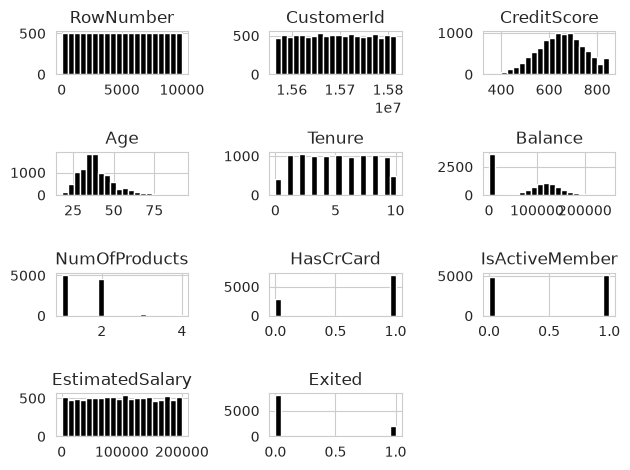

In [9]:
# Histogram for numerical values distribution
df.hist(bins=20, color="black")
plt.tight_layout()
plt.show()

**Observations**

- Identifiers columns (RowNumber, CustomerId) are to be blacklisted later from the actual features list for when a model is picked for training (Also depends on the model, Tree based one might not need this restriction). These only serve as book keeping for the dataset owner. (they could've been dropped in a diff filtered DF as well)
- **CreditScore** displays an almost normal distribution, with the caveat that there is a spike. However, the spike seems to be a cap at the value 850, rather than outliers. To confirm this we can execute below code:

In [10]:
df[df.CreditScore == 850].shape

(233, 14)

Code above confirms the CreditScore column is a ceiling rather than outliers.

- **Tenure** would look like a small flat distribution, however, without bi-variate analysis (see later) we cannot rule this has a correlation/impact with the target variable for churn (exited).
- **Balance** confirms the shape and the spike from the statistical analysis at the graphical level. Above zero we can see a fairly clean, roughly bell-shape distribution
- **NumOfProducts, HasCrCard, IsActiveMember** as oddly distributed as they might seen, they don't inform in this type of analysis of potential impact/correlation with the target variable. Best to hold conclusions
- **EstimatedSalary** being almost a flat distribution on the plot hints at potentially a synthetically generated column for the dataset composition.

In [12]:
# Categorical columns
categorical_columns = df.drop(columns="Surname").describe(include=["object", "str"])

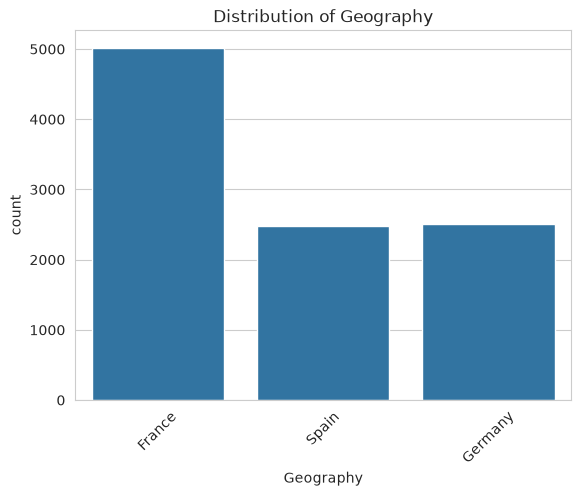

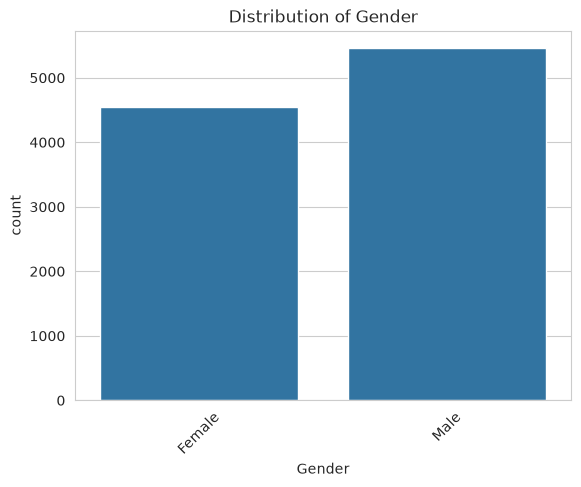

In [13]:
# Visualize with Count Plots and draw observations
for col in categorical_columns:
    sns.countplot(data=df, x=col)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()

In [14]:
# Visualize percentages of the plots
df.Geography.value_counts(normalize=True)

Geography
France     0.5014
Germany    0.2509
Spain      0.2477
Name: proportion, dtype: float64

Visualization of the percentages corresponding to the count plots yields more information, i.e.: for the _Geography_ feature, France has 50% of the customer base, the rest is split between Germany and Spain.

In [15]:
# Scatter plot for numerical columns
numerical_columns = df.drop(['RowNumber', 'CustomerId'], axis=1).describe(include="number").columns

**Cardinality**

In [16]:
df[['Gender', 'Geography', 'Surname']].nunique()

Gender          2
Geography       3
Surname      2932
dtype: int64

_Gender_ as seen in the plot and snippet above, in this case, it has binary cardinality, which makes it a good candidate for Ordinal Encoding.

_Geography_ has low nominal cardinality, which will differ in encoding as the previous categorical feature. To avoid the model treating them as numerical meaningful values, one-hot-encoding is likely the appropriate encoding strategy (see below)

Lastly, _Surname_ has a high cardinality but it can be disregarded as it's a personal identifier.

### Bivariate Analysis

#### Correlation Matrix

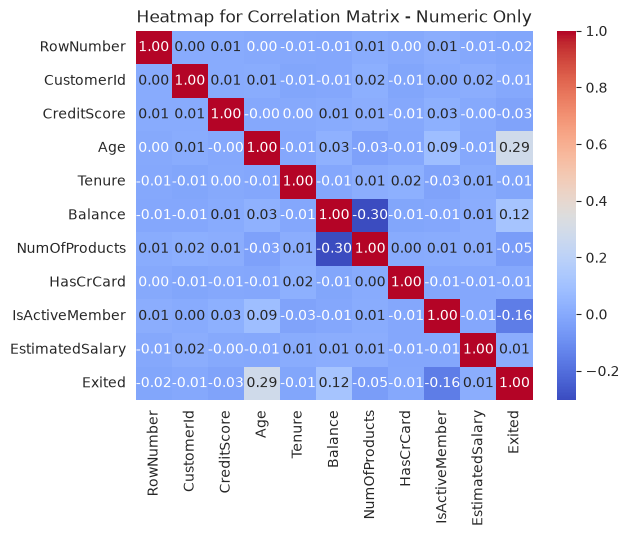

In [17]:
# Correlation Matrix (Pearse default) in heatmap
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Heatmap for Correlation Matrix - Numeric Only")
plt.show()

At a bird's eye view, two notable strong correlation candidates: _age_ and _balance_ (assumed to be a bank balance) 

In [18]:
# Numerical columns
numerical_columns = df.describe(include="number").columns
# Drop id columns and target one
numerical_columns = numerical_columns.drop(["Exited", "RowNumber", "CustomerId"])
numerical_columns

Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary'],
      dtype='str')

##### Visualization

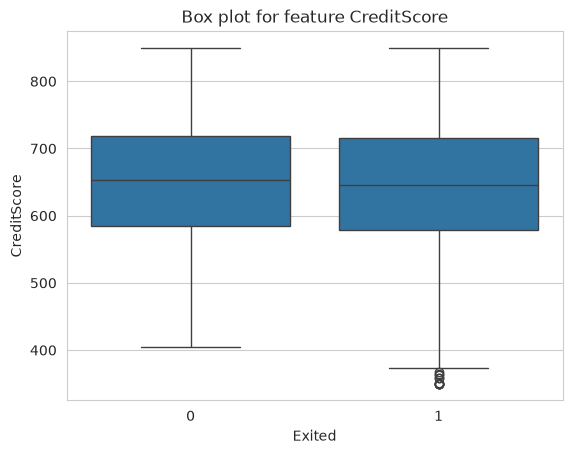

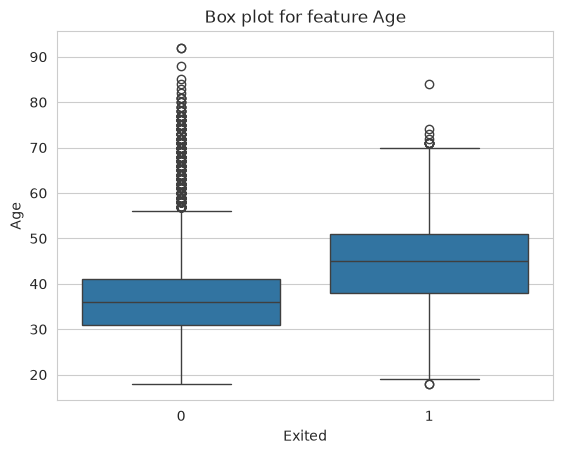

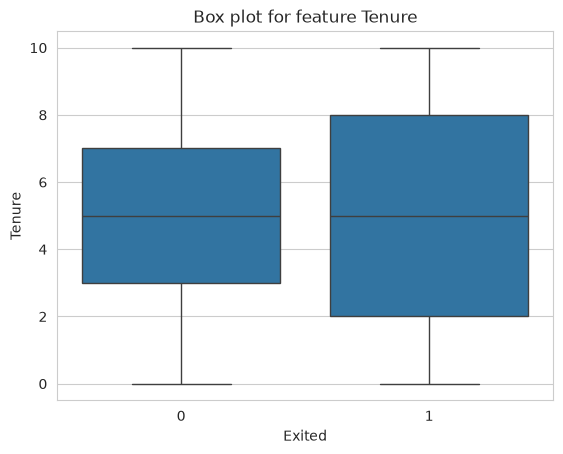

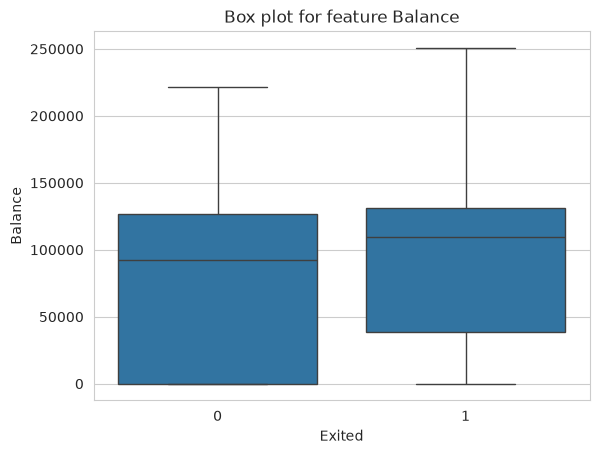

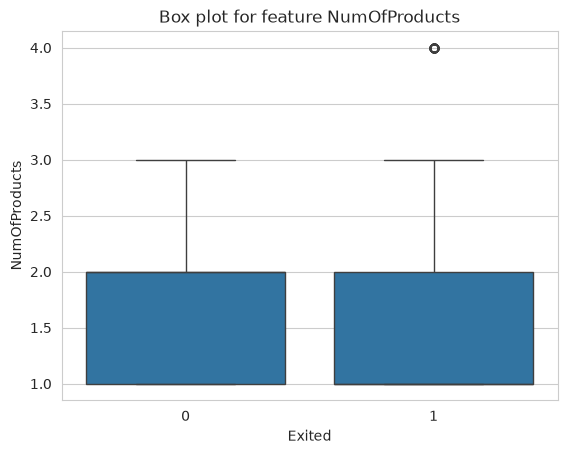

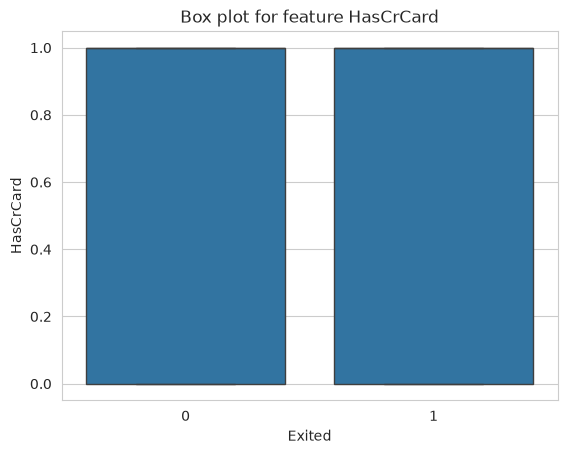

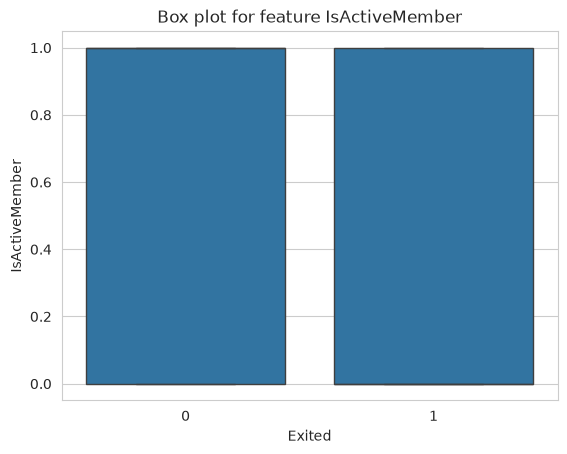

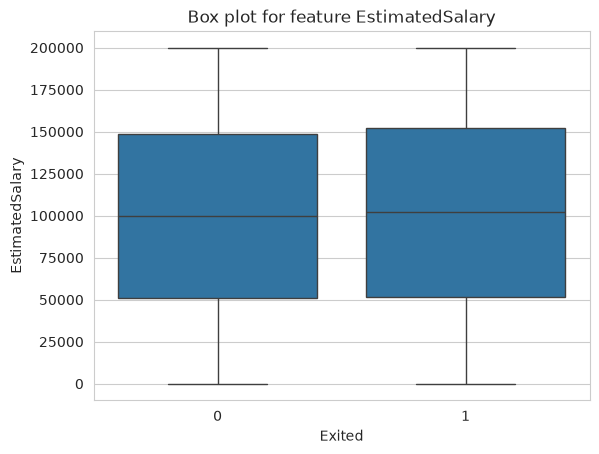

In [19]:
# BoxPlot per column - expanded, one per each
for col in numerical_columns:
    sns.boxplot(data=df, x="Exited", y=col)
    plt.title(f"Box plot for feature {col}")
    plt.show()

The box plot highlights what the correlation matrix did as well, particularly:

- _Age_ is a factor for churning: from 40 to 50/55 (and some older outliers), the churn is greater. Conversely, from 30 to 40 (and 60 onwards) the non-churning is more visible.

- _Balance_: from 50k up to 130k (approximately), there is some churning visible, though is parallel to non-churning on the same range

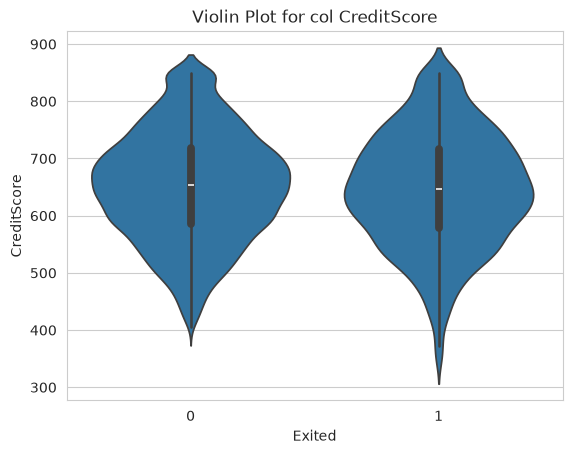

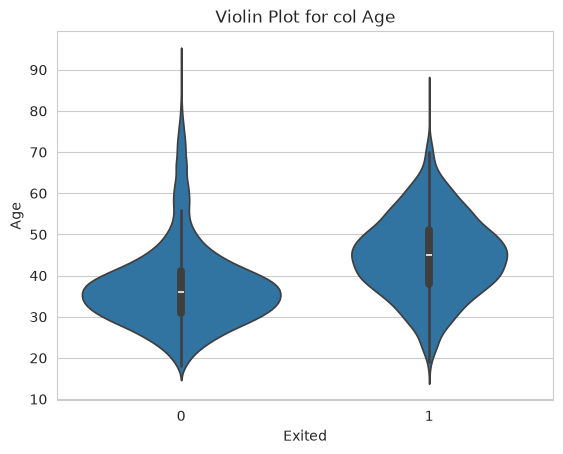

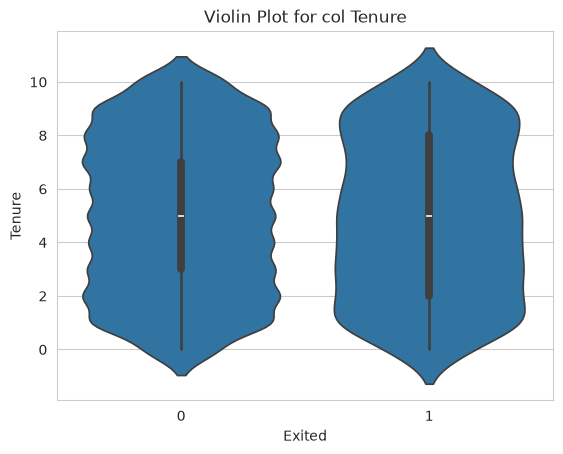

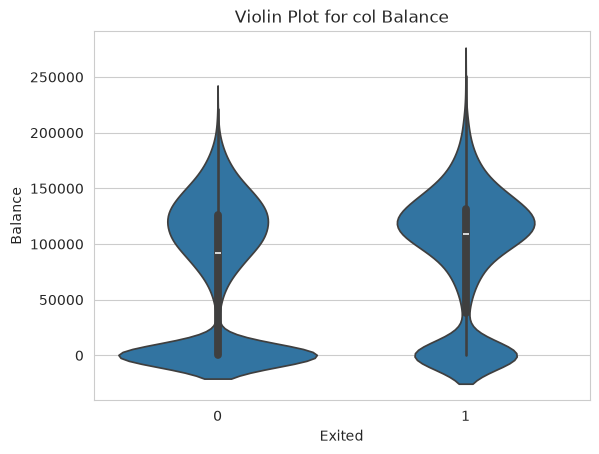

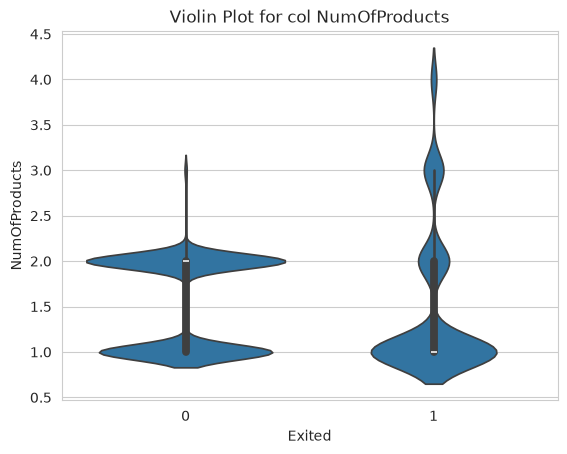

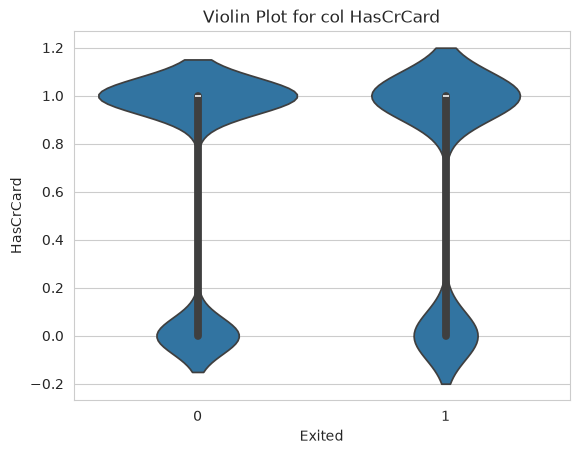

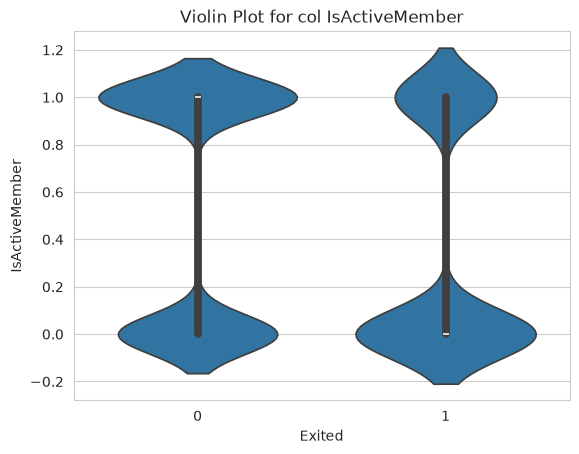

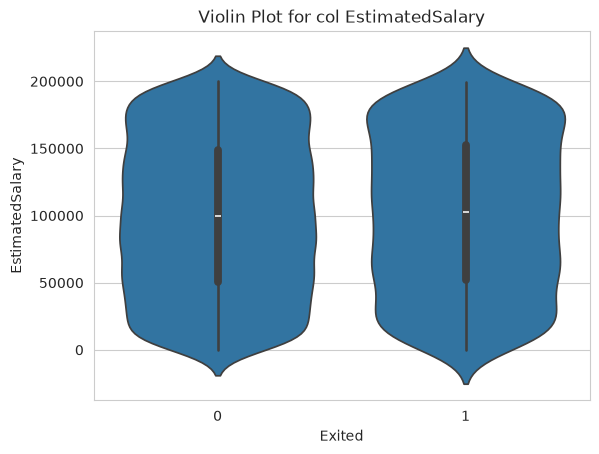

In [20]:
for col in numerical_columns:
    sns.violinplot(data=df, x="Exited", y=col)
    plt.title(f"Violin Plot for col {col}")
    plt.show()

Some observations from the Violin Plot:

- The _Age_ feature already seen in the Box Plot show up again, with the added distribution.
- Being an _ActiveMember_ might influence slightly staying with the company
- Then number of products has a small nudge on the churning (fewer more churning)

It can be helpful to see the shape of the _Age_ feature relationship with churning by grouping and plotting on a Bar Chart separated by bins:

<Axes: xlabel='Age', ylabel='Exited'>

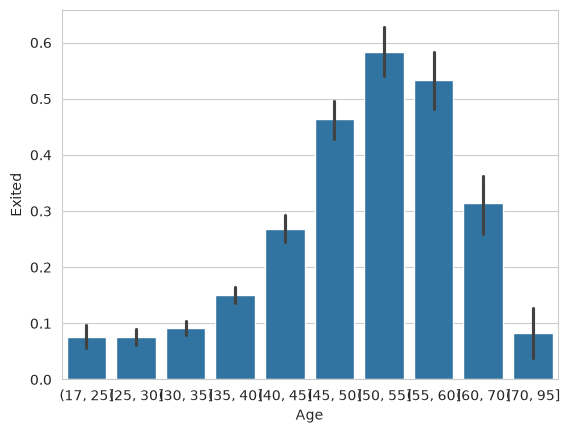

In [21]:
bins = [17,25,30,35,40,45,50,55,60,70,95]
age_bucket = pd.cut(df.Age, bins)
sns.barplot(x=age_bucket, y=df.Exited)

The _Age_ feature expanded into this plot shows that from 45/50 until 55/60 at least 50% of that customer bucket churned (or more), which is not a trivial observation to keep in mind.

---

Also, from the Univariate analysis section: _Balance_ has a big spike at exactly zero (36% of customers). 

That spike means Balance could be answering two different questions at once — "does having a balance at all matter?" and "does the amount matter?" — and Balance's single correlation score (0.119) blends both together without telling which one is real. 

One more plots can help investigat this a bit further: 
- A bar plot of churn rate for "has a balance" vs. "doesn't"

<Axes: xlabel='Balance', ylabel='Exited'>

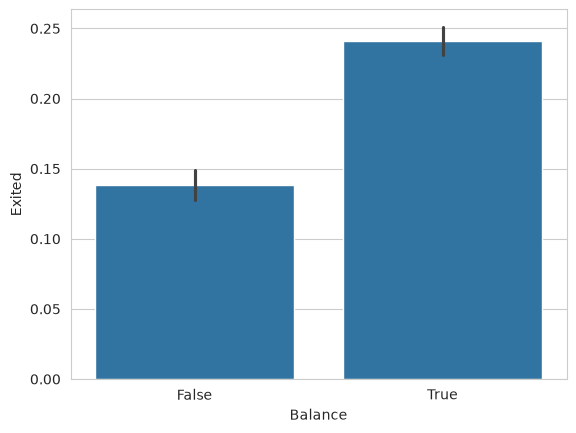

In [22]:
# Plot to analyse the first investigation of above
sns.barplot(x=(df.Balance > 0), y=df.Exited)

Having a _Balance_ has around 24.1% (double the rate) chance of churning in comparison to not having one

##### Categorical Bivariate Analysis

As surname was discarded by the reasons explained above, we can do a bivariate analysis with the remaining categorical featues, as follows:

<Axes: xlabel='Geography', ylabel='Exited'>

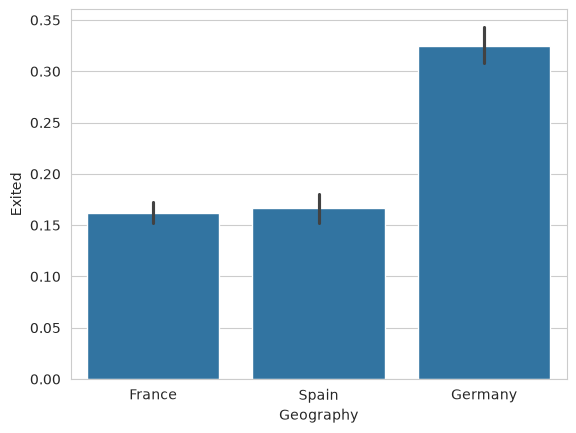

In [23]:
# Plot for Geography
sns.barplot(data=df, x="Geography", y="Exited")

In univariate analysis the counts per country yielded as follows:

Geography
- France     0.5014
- Germany    0.2509
- Spain      0.2477

Linking this to the above chart, we can see that Germany has around 32.44% (see below code snippet) of customers churning, not being the biggest population. 

In [24]:
df.groupby('Geography').Exited.mean()

Geography
France     0.161548
Germany    0.324432
Spain      0.166734
Name: Exited, dtype: float64

In [25]:
from scipy.stats import chi2_contingency
chi2_contingency(pd.crosstab(df.Geography, df.Exited))

Chi2ContingencyResult(statistic=np.float64(301.25533682434536), pvalue=np.float64(3.8303176053541544e-66), dof=2, expected_freq=array([[3992.6482, 1021.3518],
       [1997.9167,  511.0833],
       [1972.4351,  504.5649]]))

We can see by running chi-square and p-value that _Geography_ has a real, not-by-chance effect on churn overall — and looking at the actual rates, that effect is clearly concentrated in Germany, since France and Spain look similar to each other while Germany stands apart.

Lastly, we can do a similar analysis for _Gender_:

<Axes: xlabel='Gender', ylabel='Exited'>

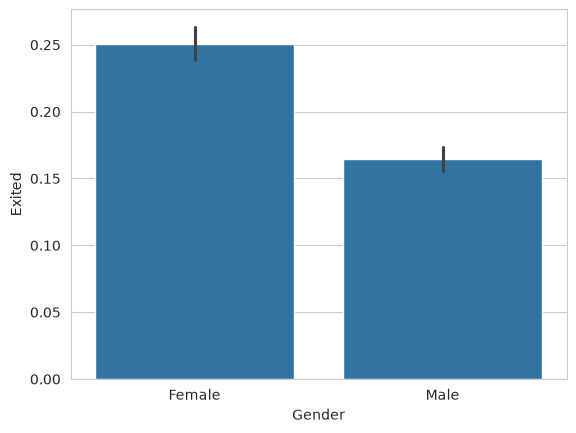

In [26]:
sns.barplot(data=df, x="Gender", y="Exited")

In [27]:
df.groupby("Gender").Exited.mean()

Gender
Female    0.250715
Male      0.164559
Name: Exited, dtype: float64

In [28]:
chi2_contingency(pd.crosstab(df.Gender, df.Exited))

Chi2ContingencyResult(statistic=np.float64(112.91857062096116), pvalue=np.float64(2.2482100097131755e-26), dof=1, expected_freq=array([[3617.5909,  925.4091],
       [4345.4091, 1111.5909]]))

Females churn more than males, which the statistical analysis of above confirmed.

### Summary of Exploratory Findings

Before proceeding to feature engineering, it is worth consolidating what the exploratory analysis has established, so that the transformations that follow rest on observed evidence.

The dataset comprises ten thousand customers of a retail bank, of whom 20.37 per cent had exited by the time of measurement — a moderate imbalance worth bearing in mind when evaluation metrics are chosen later.

**Credit score.** The distribution carries a ceiling at 850, the maximum attainable score, where 2.33 per cent of customers sit. This concentration reflects a ceiling built into the scoring system itself, and is best treated as a genuine feature of the data.

**Age.** Age is among the strongest drivers of churn, though the relationship is non-linear, a shape the correlation coefficient alone (0.285) understates. Churn rises through the forties, peaks in the fifty-to-fifty-five bracket, where over half of customers in that band eventually leave, and falls away again beyond sixty.

**Balance.** The balance column is zero-inflated, with 36.17 per cent of customers holding exactly zero — a pattern consistent with a distinct customer segment. Splitting the population on this basis shows that the presence of a balance carries most of the signal: customers with a positive balance churn at 24.08 per cent, against 13.82 per cent for those without. Among customers who do hold a balance, its size adds little further association with the outcome.

**Geography and gender.** Both variables carry associations with churn confirmed by a chi-square test to be unlikely to arise by chance. Germany, a quarter of the customer base, churns at 32.44 per cent, close to double the rate seen in France and Spain, both near sixteen per cent (χ² = 301.26, p ≈ 3.8 × 10⁻⁶⁶). Female customers churn at 25.07 per cent, male customers at 16.46 per cent (χ² = 112.92, p ≈ 2.2 × 10⁻²⁶).

**Product holdings and engagement.** `NumOfProducts` carries a pronounced signal: customers holding three or four products churn at 82.7 per cent and 100 per cent respectively, though together they make up only 3.26 per cent of the customer base. The bulk of customers hold one or two products, and the contrast between these groups is itself substantial — 27.7 per cent churn among single-product holders, against 7.6 per cent among those holding two. Active membership shows a comparable gap: inactive members churn at 26.85 per cent, active members at 14.27 per cent. Credit card ownership shows almost no gap between holders and non-holders and appears to add little on its own.

**Tenure and estimated salary.** Both variables sit close to the overall churn rate at every value examined and show little discernible relationship with the outcome. Estimated salary, whose distribution is close to symmetric and uniform in shape, correlates with churn only negligibly (r ≈ 0.012).

These findings inform the feature engineering that follows: `Geography` and `Gender` require encoding for the model to consume, a derived indicator for the presence of a balance is under consideration, and the random forest under evaluation first will be given the fuller feature set, with the pruning of any weak contributors left to its own feature importances.

### Feature Engineering

We'll work briefly on the techniques that we'll apply on a pipeline at the end when a model is finally selected to ship the product (and for demonstration purposes)

In [162]:
# Encode the Gender feature
from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder()
df["Gender"] = ordinal_encoder.fit_transform(df[["Gender"]])

##### One-Hot encoding

In [ ]:
# Use pd.Dummies for one-hot encoding -> a non binary categorical feature
# Also, return a new DF to keep the original untouched for diff models training down the line
df_fe = pd.get_dummies(df, columns=['Geography'], drop_first=True)

In [164]:
# Peek at the resulting dataframe structure
df_fe.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Gender', 'Age',
       'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Exited', 'Geography_Germany', 'Geography_Spain'],
      dtype='str')

#### Feature Selection

We remove the noisy feautes (like RowNumber, CustomerId, Surname) and keep the rest for the time being.

**As we'll be training a RandomForest first**, the training algorithm tied to it can handle irrelevant features well.

In [165]:
features = ['CreditScore', 'Gender', 'Age',
       'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Exited', 'Geography_Germany', 'Geography_Spain']